# Density functional theory

Companion notebook to Chapter 8 of *Quantum mechanics for many-particle
systems*.  Every number quoted in the chapter is produced here; the code is
the same as in `BookManybody/BookMaterial/Programs/dft.py`.

The theme is that the local density approximation is not a black box but
something one *builds*, from a system that can be solved exactly.  We build it
twice: once for the three-dimensional electron gas of Chapter 6, where the
answer is analytic, and once numerically for the one-dimensional trap of
Chapters 2 and 6, so that Kohn-Sham, Hartree-Fock and the exact answer can be
compared for one and the same Hamiltonian.

Contents:

1. Where the LDA comes from
2. The exchange hole and its sum rule
3. Building a functional for the model interaction
4. Solving the Kohn-Sham equations
5. The self-interaction error
6. How good is the local approximation?
7. Thomas-Fermi, and why orbitals came back

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join("..", "BookManybody", "BookMaterial", "Programs"))
import dft

np.set_printoptions(precision=6, suppress=True, linewidth=120)

## 1. Where the local density approximation comes from

$$E_{\rm xc}^{\rm LDA}[n] = \int d^3r\, n(\mathbf r)\,
  \epsilon_{\rm xc}\!\left(n(\mathbf r)\right),$$

with $\epsilon_{\rm xc}$ taken from the uniform gas.  For exchange the answer
is analytic,

$$\epsilon_x(n) = -\frac34\left(\frac{3}{\pi}\right)^{1/3}n^{1/3},$$

and evaluated on the uniform gas it must reproduce the $-0.916/r_s$ of
Chapter 6.  That it does is a tautology — the LDA is *defined* to be exact
there — but it is a useful check that the conventions line up.

In [2]:
dft.demo_lda_from_the_gas()

1. Where the local density approximation comes from
The exchange energy per particle of the three-dimensional gas,
   eps_x(n) = -(3/4)(3/pi)^(1/3) n^(1/3),
is the whole content of the local density approximation for
exchange.  Evaluated on the uniform gas it must reproduce the
0.916/r_s of chapter 6, and it does:

     r_s     eps_x [Ha]     eps_x [Ry]     -0.916/r_s
  1.0000      -0.458165      -0.916331      -0.916000
  2.0000      -0.229083      -0.458165      -0.458000
  4.0000      -0.114541      -0.229083      -0.229000
  4.8253      -0.094951      -0.189901      -0.189833
  6.0000      -0.076361      -0.152722      -0.152667

the coefficient itself: 0.916331
against the 0.9163 exchange coefficient of chapter 6.  This is not a
coincidence but a tautology: the LDA is *defined* so that it is
exact for the uniform gas.  What is not obvious, and what makes it
useful, is that it remains good when the density varies.

The Thomas-Fermi kinetic energy density comes from the same
calcula

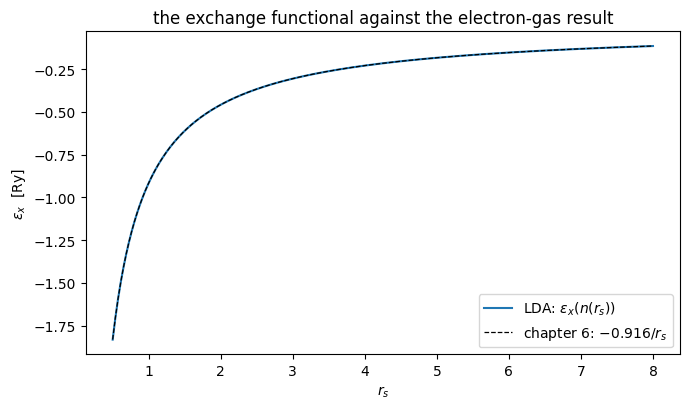

In [3]:
rs = np.linspace(0.5, 8.0, 400)
n = dft.ExchangeLDA3D.density_from_rs(rs)
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(rs, 2 * dft.ExchangeLDA3D.eps_x(n), label=r"LDA: $\epsilon_x(n(r_s))$")
ax.plot(rs, -0.916 / rs, "k--", lw=0.9, label=r"chapter 6: $-0.916/r_s$")
ax.set_xlabel(r"$r_s$"); ax.set_ylabel(r"$\epsilon_x$  [Ry]")
ax.set_title("the exchange functional against the electron-gas result")
ax.legend(); fig.tight_layout(); plt.show()

## 2. The exchange hole

Each electron moves inside a hole in the density of its neighbours.  For the
uniform gas the pair correlation function is exact at the Hartree-Fock level,

$$g(y) = 1 - \frac92\left[\frac{\sin y - y\cos y}{y^3}\right]^2,
\qquad y = k_F s,$$

with $g(0)=\tfrac12$: same-spin electrons never coincide, opposite-spin ones
are uncorrelated at this level.  The hole contains exactly one missing
electron, and that sum rule is a large part of why local functionals work at
all — the energy depends mostly on the *charge* of the hole, which is fixed
exactly, and only weakly on its shape.

In [4]:
dft.demo_exchange_hole()

2. The exchange hole
Exchange is not a mysterious correction: it is the statement that
each electron carries around it a region depleted of electrons of
the same spin.  For the uniform gas the pair correlation function
is known exactly at the Hartree-Fock level,
   g(s) = 1 - (9/2)[(sin y - y cos y)/y^3]^2,   y = k_F s.

   k_F s         g(s)   interpretation
    0.00     0.500000   g(0) = 1/2: same spins never coincide
    0.50     0.524471   
    1.00     0.591838   
    2.00     0.786732   
    4.00     0.996208   
    8.00     0.999920   
   16.00     0.999939   the hole has healed

The hole integrates to exactly one missing electron,
   n int d^3s [g(s) - 1] = (4 / 3 pi) int_0^inf dy y^2 [g(y) - 1]
                         = -1,
which is the sum rule that any decent approximate functional must
respect.  Checking it numerically:


   (4 / 3 pi) int dy y^2 [g(y) - 1] = -0.997615

The exact value of the integral is -pi/6 times 9/2, and the
prefactor turns it into exactly -1.  Local functionals are built
to satisfy this sum rule even when they get the shape of the hole
wrong, which is a large part of why they work at all.


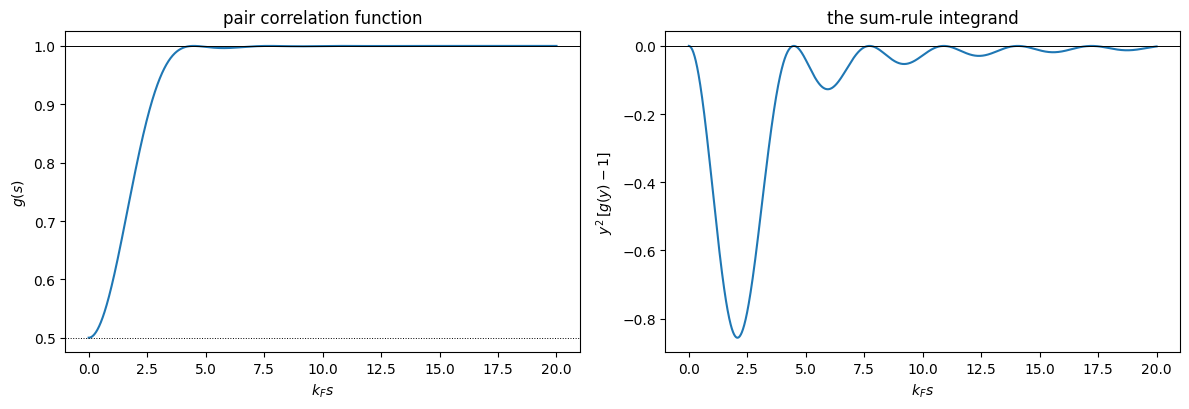

In [5]:
y = np.linspace(1e-6, 20.0, 2000)
g = dft.exchange_hole(y)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(y, g)
ax[0].axhline(1.0, color="k", lw=0.7); ax[0].axhline(0.5, color="k", ls=":", lw=0.7)
ax[0].set_xlabel(r"$k_F s$"); ax[0].set_ylabel("$g(s)$")
ax[0].set_title("pair correlation function")
ax[1].plot(y, y**2 * (g - 1.0))
ax[1].axhline(0.0, color="k", lw=0.7)
ax[1].set_xlabel(r"$k_F s$"); ax[1].set_ylabel(r"$y^2\,[g(y)-1]$")
ax[1].set_title("the sum-rule integrand")
fig.tight_layout(); plt.show()

## 3. Building a functional for the model interaction

The trap of Chapters 2 and 6 uses a softened Coulomb interaction in one
dimension, for which no tabulated functional exists.  So we do what is done in
practice: solve the uniform gas once, tabulate, interpolate.  For a spinless
1D gas $k_F = \pi n$ and $\rho^{(1)}(s) = \sin(k_F s)/\pi s$, so

$$\epsilon_x(n) = -\frac1n\int_0^\infty ds\, v(s)
  \left[\frac{\sin(k_F s)}{\pi s}\right]^2 .$$

In [6]:
dft.demo_lda_1d()

3. Building a local functional for the model interaction
The trap of chapters 2 and 6 has a softened Coulomb interaction in
one dimension, for which no closed-form exchange functional
exists.  So we do what is done in practice: solve the uniform gas
once, tabulate, and interpolate.  For a spinless one-dimensional
gas k_F = pi n, the density matrix is sin(k_F s)/(pi s), and
   eps_x(n) = -(1/n) int_0^inf ds v(s) [sin(k_F s)/(pi s)]^2.



       n       eps_x(n)         v_x(n)
   0.050    -0.17352608    -0.29740316
   0.100    -0.27855522    -0.45906496
   0.200    -0.42332628    -0.65789106
   0.400    -0.59557914    -0.84878595
   0.800    -0.75884371    -0.96587633
   1.500    -0.86548980    -0.99703512
   2.500    -0.91895548    -0.99989688

Two checks.  The interpolated energy density must reproduce the
integrated values it was built from, and the potential must be
the derivative of the energy density:
   max |interpolated - integrated| = 1.47e-09
   max |v_x - d(n eps_x)/dn|       = 1.96e-10


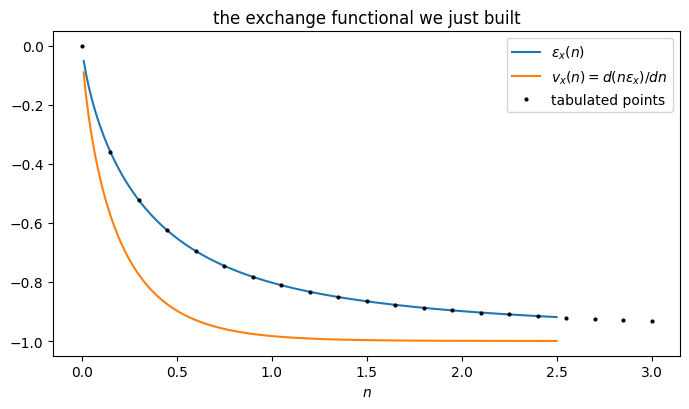

In [7]:
lda = dft.ExchangeLDA1D()
n = np.linspace(0.01, 2.5, 400)
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(n, lda.eps_x(n), label=r"$\epsilon_x(n)$")
ax.plot(n, lda.v_x(n), label=r"$v_x(n) = d(n\epsilon_x)/dn$")
ax.plot(lda.grid[::12], lda.table[::12], "k.", ms=4,
        label="tabulated points")
ax.set_xlabel("$n$"); ax.set_title("the exchange functional we just built")
ax.legend(); fig.tight_layout(); plt.show()

## 4. Solving the Kohn-Sham equations

$$\left(-\frac{\hbar^2}{2m}\nabla^2 + v_{\rm KS}(\mathbf r)\right)
  \psi_i = \varepsilon_i\psi_i,
\qquad
v_{\rm KS} = v_{\rm ext} + v_{\rm H}[n] + v_{\rm xc}[n],$$

iterated to self-consistency exactly as in Chapter 6.  Same trap, same basis
of eight oscillator orbitals, same interaction — so Kohn-Sham, Hartree-Fock
and (for two particles) the exact answer are directly comparable.

In [8]:
dft.demo_kohn_sham()

4. Solving the Kohn-Sham equations
The same trap, the same basis of eight oscillator orbitals and the
same interaction as the Hartree-Fock calculation of chapter 6, so
that the two can be compared directly.  For two particles the
exact answer is available as well.



  N    E(Kohn-Sham)   E(Hartree-Fock)     E(exact)   KS iter   HF iter
  1      0.54752674        0.50000000   0.50000000        56         2
  2      2.72022768        2.66308878   2.65923049        58        20
  3      6.45108052        6.39016133           --        58        20
  4     11.68602229       11.62305385           --        58        21

Kohn-Sham lies close to Hartree-Fock but not on top of it, and the
difference is not correlation -- we have put no correlation
functional in.  It is the error of treating exchange locally, plus
the self-interaction discussed below.


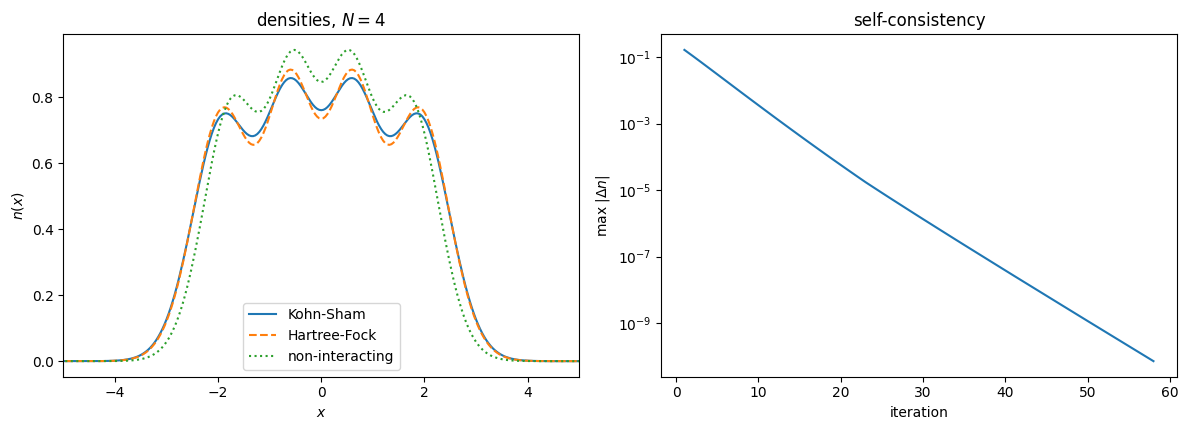

In [9]:
lda = dft.ExchangeLDA1D()
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))

ks = dft.KohnSham1D(4, lda=lda); ks.run()
hf = dft.hartree_fock(4)
grid, phi = dft.oscillator_basis(8)
n_free = (phi[:4] ** 2).sum(axis=0)
n_hf = ((phi.T @ hf["C"][:, :4]) ** 2).sum(axis=1)

ax[0].plot(grid, ks.n, label="Kohn-Sham")
ax[0].plot(grid, n_hf, "--", label="Hartree-Fock")
ax[0].plot(grid, n_free, ":", label="non-interacting")
ax[0].set_xlim(-5, 5); ax[0].set_xlabel("$x$"); ax[0].set_ylabel("$n(x)$")
ax[0].set_title("densities, $N = 4$"); ax[0].legend()

it, energies, drifts = zip(*ks.history)
ax[1].semilogy(it, drifts)
ax[1].set_xlabel("iteration"); ax[1].set_ylabel(r"max $|\Delta n|$")
ax[1].set_title("self-consistency")
fig.tight_layout(); plt.show()

## 5. The self-interaction error

For one particle there is nothing to interact with, so the exact energy is the
oscillator ground state, $0.5$.  Hartree-Fock gets this identically right —
the direct and exchange terms cancel term by term.  A local functional cannot,
because it sees only the density, and the density of one electron is
indistinguishable from the density of half of two.

In [10]:
dft.demo_self_interaction()

5. The self-interaction error
For one particle there is nothing to interact with, so the exact
energy is the oscillator ground state, 0.5.  Hartree-Fock gets
this right identically: the direct and exchange terms cancel term
by term.  A local exchange functional cannot, because it knows
only the density, and the density of one electron looks exactly
like the density of half of two.



   exact                     0.50000000
   Hartree-Fock              0.50000000
   Kohn-Sham (LDA x)         0.54752674

   the Kohn-Sham pieces:
      Hartree energy         0.60855522
      exchange energy       -0.56166291
      sum                    0.04689232   (should vanish)
      particle number        1.00000000

The residue is the self-interaction error.  It is the reason plain
LDA overbinds anions, underestimates barriers and gives band gaps
that are too small, and it is what self-interaction corrections and
hybrid functionals -- which put back a fraction of exact exchange --
are designed to remove.


The residue is what makes plain LDA overbind anions, underestimate reaction
barriers and give band gaps that are too small: an electron is spuriously
repelled by itself and spreads out to reduce that repulsion.  Removing it is
the business of self-interaction corrections and of hybrid functionals, which
mix back a fraction of exact exchange.

## 6. How good is the local approximation?

We can isolate the error of *locality* alone by evaluating, on one and the
same density, both the exact exchange energy of the determinant and the local
estimate.

In [11]:
dft.demo_local_approximation()

6. How good is the local approximation?
We can isolate the error of locality by comparing, on the *same*
density, the exact exchange energy of a determinant with the local
estimate.  Take the Kohn-Sham orbitals, compute both, and look at
the ratio.



  N     E_x (exact)       E_x (LDA)     ratio
  1     -0.60855522     -0.56166291    0.9229
  2     -1.33077771     -1.27749456    0.9600
  3     -2.11087395     -2.05548416    0.9738
  4     -2.92523775     -2.86866697    0.9807

The local approximation recovers most of the exchange energy, and
it recovers more of it as the particle number grows: the ratio
climbs from 0.92 to 0.98 between one and four particles.  That is
exactly what the construction promises -- the density becomes
smoother on the scale of the local Fermi wavelength, so the
uniform-gas estimate becomes more appropriate.  For one particle
it is worst, because there the exchange energy is nothing but the
cancellation of a spurious self-interaction.  In three dimensions
the corresponding ratio is close to 0.9 for atoms, which is why
gradient corrections were introduced.


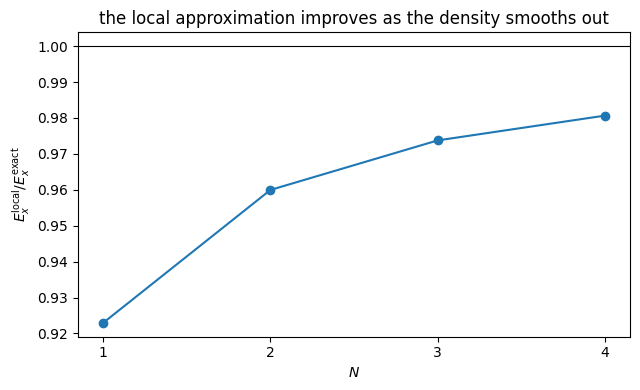

In [12]:
Ns = [1, 2, 3, 4]
ratios = []
for N in Ns:
    ks = dft.KohnSham1D(N, lda=lda); ks.run()
    vbar = dft.trap_two_body(8)
    occ = ks.C[:, :N]
    both = 0.5 * np.einsum("ai,bj,abcd,ci,dj->", occ, occ, vbar, occ, occ)
    exact_x = both - ks.hartree_energy(ks.n)
    ratios.append(ks.exchange_energy(ks.n) / exact_x)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(Ns, ratios, "o-")
ax.axhline(1.0, color="k", lw=0.8)
ax.set_xticks(Ns); ax.set_xlabel("$N$")
ax.set_ylabel(r"$E_x^{\rm local} / E_x^{\rm exact}$")
ax.set_title("the local approximation improves as the density smooths out")
fig.tight_layout(); plt.show()

## 7. Thomas-Fermi, and why orbitals came back

Thomas-Fermi applies the local approximation to the kinetic energy as well,
which removes orbitals entirely and leaves an algebraic equation for $n(x)$.
It is enormously cheaper — and it fails, not mainly in magnitude but in
structure: the density it produces has no shells at all, and Teller proved
that within the model no molecule is bound.  The Kohn-Sham construction exists
precisely to avoid this, by keeping orbitals for the one term that a local
approximation handles badly.

In [13]:
dft.demo_thomas_fermi()

7. Thomas-Fermi, and why orbitals came back
The Thomas-Fermi model applies the local approximation to the
kinetic energy as well.  For the one-dimensional trap the kinetic
density is t[n] = (pi^2/6) n^3, and minimising
   E[n] = int dx {t[n] + x^2 n / 2} + E_H[n] + E_x[n]
gives an algebraic equation for n(x) with no orbitals at all.

The trouble is visible already for non-interacting particles,
where the exact kinetic energy is known:
  N    T (exact)   T (Thomas-Fermi)     ratio
  1     0.250000           0.302300    1.2092
  2     1.000000           1.074844    1.0748
  3     2.250000           2.340025    1.0400
  4     4.000000           4.101805    1.0255
  6     9.000000           9.120038    1.0133
  8    16.000000          16.134286    1.0084

Thomas-Fermi overshoots, badly for one particle and by less than
one per cent by eight, approaching the exact value from above as
the density smooths out.  But the error in magnitude is not the
real problem.  What the model misses is stru

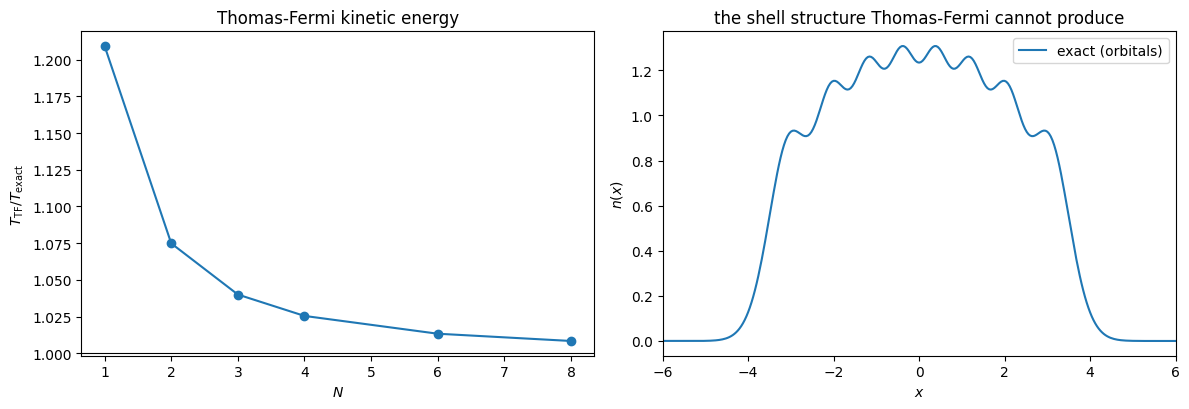

In [14]:
grid, phi = dft.oscillator_basis(8)
dx = grid[1] - grid[0]
Ns = np.array([1, 2, 3, 4, 6, 8])
ratio = []
for N in Ns:
    n = (phi[:N] ** 2).sum(axis=0)
    exact = sum(k + 0.5 for k in range(N)) - 0.5 * float(n @ grid**2) * dx
    ratio.append(float(dft.ThomasFermi.kinetic_density(n).sum()) * dx / exact)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(Ns, ratio, "o-")
ax[0].axhline(1.0, color="k", lw=0.8)
ax[0].set_xlabel("$N$"); ax[0].set_ylabel(r"$T_{\rm TF} / T_{\rm exact}$")
ax[0].set_title("Thomas-Fermi kinetic energy")

n8 = (phi[:8] ** 2).sum(axis=0)
ax[1].plot(grid, n8, label="exact (orbitals)")
ax[1].set_xlim(-6, 6); ax[1].set_xlabel("$x$"); ax[1].set_ylabel("$n(x)$")
ax[1].set_title("the shell structure Thomas-Fermi cannot produce")
ax[1].legend()
fig.tight_layout(); plt.show()

## The full program

Everything above lives in `BookManybody/BookMaterial/Programs/dft.py`, which
runs as a script and prints all seven demonstrations of the chapter.

In [15]:
print(open(dft.__file__).read())

"""
Density functional theory: densities, functionals and the Kohn-Sham equations.

Companion code to chapter 8 of *Quantum mechanics for Many-particle Systems*.

Three things are done here.

First, the local density approximation is *derived* rather than quoted.  For
the three-dimensional electron gas the exchange energy per particle is
obtained from the one-body density matrix of the filled Fermi sea and checked
against the analytic 0.916/r_s of chapter 6.  The same construction is then
carried out numerically for a one-dimensional gas interacting through the
softened Coulomb potential used in chapters 2 and 6, which produces a
tabulated exchange functional for exactly that system.

Second, the Kohn-Sham equations are solved self-consistently in the same
oscillator basis as the Hartree-Fock calculation of chapter 6, so that
Hartree-Fock, Kohn-Sham and (for two particles) the exact answer can be
compared for one and the same Hamiltonian.

Third, the two characteristic errors of the lo